# Задание 02. Ускорение обучения — notebook для Kaggle

Все пять Python-файлов задания объединены в редактируемые ячейки. Классы и функции
вызываются напрямую; скачивать или редактировать `.py` файлы для работы не требуется.
Учебные заглушки `pass` и `YOUR CODE HERE` сохранены. Их нужно заполнить самостоятельно.

Исходники: [Tasks/task2](https://github.com/mmp-effml-team/mmp_effml_fall/tree/6f6e706c9b3d50aa47c666c1e1d4b8f9b0ae2637/Tasks/task2),
commit `6f6e706c9b3d50aa47c666c1e1d4b8f9b0ae2637`. Условие ниже взято из исходного `README.md`.

После изменения класса или функции выполните его ячейку заново. Если объект уже создан,
создайте его повторно. Для чистого эксперимента перезапустите kernel и выполните ячейки по порядку.

# `Введение в Эффективные Системы Машинного обучения`

## `Задание 02. Ускорение обучения`


Дата выдачи: __23 сентября__

Мягкий дедлайн: __05 октября 15:00__

Стоимость: __10 баллов__ (основная часть заданий) + __1 балл__ (дополнительные задания).

#### `Москва, 2026`

##### По всем вопросам писать `@trandelik`

Задание основано на [аналогичном задании курса ШАДа 2025 года](https://github.com/mryab/efficient-dl-systems/tree/2025/week03_fast_pipelines/homework).

### `Формат сдачи`

Архив с кодом + отчет в формате PDF.

## 1. Подготовка Kaggle

1. Создайте Kaggle Notebook и импортируйте этот `.ipynb` через **File → Import Notebook**.
2. В настройках выберите GPU accelerator и включите **Internet** для установки недостающих
   пакетов и первой загрузки `bert-base-uncased`.
3. Скачайте именно файл из [датасета задания](https://disk.360.yandex.ru/d/fL9HkaunY7o29g).
   Добавьте его в notebook через **Add Input**. В ячейке параметров ниже задайте `DATA_PATH`.
   Если единственный файл с именем `validation-00000-of-00001.txt` найден автоматически,
   его путь будет подставлен сразу.
4. Заполните заглушки. По умолчанию `RUN_TRAINING = False`, поэтому выполнение всех ячеек
   определяет классы и функции, но не начинает незавершённое обучение.
   После реализации установите `RUN_TRAINING = True` и выполните notebook по порядку.

Пишите результаты, checkpoint и профиль в `WORK_DIR` (`/kaggle/working` на Kaggle).
Данные из `/kaggle/input` используйте для чтения. Для работы без Internet заранее добавьте
пакеты и файлы tokenizer как Input и укажите локальную директорию в `TOKENIZER_PATH`.

[Документация Kaggle Notebooks](https://www.kaggle.com/docs/notebooks).

### `Setup`

Во всех частях задания ваша задача обучать GPT-2-like модель на [WikiText-103](https://disk.360.yandex.ru/d/fL9HkaunY7o29g).
Необходимые для выполнения библиотеки с версиями можно найти в файле `requirements.txt`. Код использует синтаксис Python 3.10+. Вы можете использовать другое окружение, **если укажете его в отчете**. **Обязательно укажите модель GPU**.

Сохраните файл датасета по пути, который передаете через `--path` (по умолчанию `data/validation-00000-of-00001.txt`), и запускайте `train.py` из каталога соответствующей версии задания. Основные параметры эксперимента вынесены в аргументы командной строки. Режим обучения выбирается через `--kind {fp32,fp16,static,dynamic}`, а начальный или статический масштаб потерь — через `--scale`. В коде намеренно оставлены неэффективности для задания по профилированию, поэтому зафиксируйте все сделанные изменения в отчете.

### Зависимости

Оригинальный `requirements.txt`:

```text
datasets==2.9.0
einops==0.7.0
torch==2.4.0
tqdm==4.64.1
transformers==4.48.2
```

Ячейка ниже сохраняет установленный на Kaggle PyTorch с поддержкой CUDA и устанавливает
только недостающие пакеты, которые импортируются в коде. `datasets` и `einops` исходные
пять `.py` файлов не используют. Если установленная версия отличается от оригинальной,
зафиксируйте фактическое окружение в отчёте, как разрешено условием.

In [37]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("torch") is None:
    raise RuntimeError("Нужен PyTorch. На Kaggle выберите Python notebook с GPU accelerator.")

required_packages = {
    "numpy": "numpy",
    "tqdm": "tqdm==4.64.1",
    "transformers": "transformers==4.48.2",
}
missing_packages = [
    package for module, package in required_packages.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("Все необходимые пакеты уже установлены.")

Все необходимые пакеты уже установлены.


### Общие импорты

Локальные импорты `amp`, `utils`, `data_utils` заменены определениями в ячейках ниже.

In [38]:
import math
import platform
import random
import time
import gc
from collections import defaultdict
from functools import partial
from importlib.metadata import version
from pathlib import Path
from types import SimpleNamespace
from typing import Callable, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import DataLoader, IterableDataset, Sampler
from torch.utils.data.dataset import Dataset
from tqdm.auto import tqdm
from transformers import AutoTokenizer

### Окружение для отчёта

Модель GPU и фактические версии библиотек нужны для воспроизводимости экспериментов.
Эта ячейка не загружает tokenizer, датасет или модель.

In [39]:
print("Python:", platform.python_version())
for package in ("torch", "transformers", "numpy", "tqdm"):
    print(f"{package}: {version(package)}")
print("CUDA runtime:", torch.version.cuda)
if torch.cuda.is_available():
    for device_index in range(torch.cuda.device_count()):
        print(f"GPU {device_index}: {torch.cuda.get_device_name(device_index)}")
else:
    print("CUDA GPU недоступен. Определения можно редактировать; для обучения включите GPU.")

Python: 3.13.15
torch: 2.11.0+cu128
transformers: 5.16.1
numpy: 2.1.3
tqdm: 4.67.3
CUDA runtime: 12.8
GPU 0: Tesla T4
GPU 1: Tesla T4


### Параметры эксперимента

Эта ячейка заменяет аргументы командной строки `train.py`. Начальные значения соответствуют
оригиналу. `batch_size = 32` может не помещаться в память выбранной GPU: при необходимости
уменьшите его и укажите это в отчёте. При сравнении подходов сохраняйте одинаковые данные,
seed и остальные условия.

`MAX_LENGTH = 512` взят из `data_utils.py`. Если меняете его, заново выполните определения
dataset и модели: значение используется в аргументах по умолчанию.

In [40]:
MAX_LENGTH = 512
TOKENIZER_PATH = "bert-base-uncased"  # Или путь к заранее добавленному tokenizer.
INPUT_DIR = Path("/kaggle/input")
WORK_DIR = Path("/kaggle/working") if Path("/kaggle/working").is_dir() else Path.cwd()

data_candidates = sorted(INPUT_DIR.rglob("validation-00000-of-00001.txt")) if INPUT_DIR.is_dir() else []
DATA_PATH = "/kaggle/input/datasets/axilles60/wikitext-103-raw-v1/wikitext-103-raw-v1/validation-00000-of-00001.txt"
# Если нужно, замените DATA_PATH на точный путь к файлу из Add Input.

CONFIG = SimpleNamespace(
    kind="fp32",          # fp32 | fp16 | static | dynamic
    batch_size=32,
    num_epochs=1,
    scale=65536.0,
    factor=2.0,
    patience=80,
    min_scale=1.0,
    max_scale=2.0**24,
    dataloader="base",     # base | standard | balanced | sequenced
    path=DATA_PATH,
    k=20,
)
RUN_TRAINING = True

print("Параметры:", vars(CONFIG))
print("WORK_DIR:", WORK_DIR)
if len(data_candidates) > 1:
    print("Найдено несколько файлов; укажите DATA_PATH явно:", *data_candidates, sep="\n")
if not Path(CONFIG.path).is_file():
    print("Файл датасета пока не найден. Добавьте Input и задайте DATA_PATH перед обучением.")

Параметры: {'kind': 'fp32', 'batch_size': 32, 'num_epochs': 1, 'scale': 65536.0, 'factor': 2.0, 'patience': 80, 'min_scale': 1.0, 'max_scale': 16777216.0, 'dataloader': 'base', 'path': '/kaggle/input/datasets/axilles60/wikitext-103-raw-v1/wikitext-103-raw-v1/validation-00000-of-00001.txt', 'k': 20}
WORK_DIR: /kaggle/working


## 2. Language Modeling — `utils.py` и `positional_encoding.py`

### `Language Modeling (0 баллов)`

Реализуйте `LMAccuracy` и `LMCrossEntropyLoss` из файла `utils.py` (можно взять из задания по RNN курса ВвГО). Оба класса принимают необязательный `loss_mask`; он отмечает допустимые переходы между соседними токенами в упакованных последовательностях.

Также реализуйте `PositionalEncoding` из файла `positional_encoding.py` (можно адаптировать из задания по Conformer курса ВвГО).

### LMCrossEntropyLoss

Источник: `utils.py` → `LMCrossEntropyLoss`.

In [41]:
class LMCrossEntropyLoss(torch.nn.CrossEntropyLoss):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
    def forward(self, outputs, tokens, tokens_lens, loss_mask=None):
        """
        :param torch.Tensor outputs: Output from LM.forward. Shape: [B, T, V]
        :param torch.Tensor tokens: Batch of tokens. Shape: [B, T]
        :param torch.Tensor tokens_lens: Length of each sequence in batch
        :param torch.Tensor loss_mask: Valid next-token transitions. Shape: [B, T - 1]
        :return torch.Tensor: CrossEntropyLoss between corresponding logits and tokens
        """
        logits = outputs[:, :-1]
        targets = tokens[:, 1:]

        if loss_mask is not None:
            mask = loss_mask.to(device=tokens.device, dtype=torch.bool)
        else:
            tokens_lens = torch.as_tensor(tokens_lens, device=tokens.device)
            positions = torch.arange(tokens.shape[1] - 1, device=tokens.device)
            mask = positions[None, :] < (tokens_lens[:, None] - 1)

        return super().forward(logits[mask], targets[mask])

### LMAccuracy

Источник: `utils.py` → `LMAccuracy`.

In [42]:
class LMAccuracy(torch.nn.Module):
    def __init__(self):
        super().__init__()
        
    def forward(self, outputs, tokens, tokens_lens, loss_mask=None):
        """
        :param torch.Tensor outputs: Output from LM.forward. Shape: [B, T, V]
        :param torch.Tensor tokens: Batch of tokens. Shape: [B, T]
        :param torch.Tensor tokens_lens: Length of each sequence in batch
        :param torch.Tensor loss_mask: Valid next-token transitions. Shape: [B, T - 1]
        :return torch.Tensor: Accuracy for given logits and tokens
        """
        predictions = outputs[:, :-1].argmax(dim=-1)
        targets = tokens[:, 1:]

        if loss_mask is not None:
            mask = loss_mask.to(device=tokens.device, dtype=torch.bool)
        else:
            tokens_lens = torch.as_tensor(tokens_lens, device=tokens.device)
            positions = torch.arange(tokens.shape[1] - 1, device=tokens.device)
            mask = positions[None, :] < (tokens_lens[:, None] - 1)

        correct = ((predictions == targets) & mask).sum()
        total = mask.sum().clamp(min=1)
        return correct.float() / total

### PositionalEncoding

Источник: `positional_encoding.py` → `PositionalEncoding`.

In [43]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term[: d_model // 2])

        self.register_buffer("pe", pe)

    def forward(self, x: Tensor) -> Tensor:
        """
        Args:
            x: Tensor, shape [seq_len, batch_size, embedding_dim]
        """
        x = x + self.pe[: x.size(0)].to(x.dtype)
        return self.dropout(x)

## 3. Automatic Mixed Precision — `amp.py`

### `Automatic Mixed Precision from scratch (4 балла)`

Шаблоны всех классов находятся в `amp.py`. Вы можете редактировать любые файлы задания или создавать новые, если считаете это нужным.

**Задание**:
 - Напишите рукописную реализацию `StaticGradScaler` (1 балл)
 - Напишите рукописную реализацию `DynamicGradScaler` (1 балл)
 - Напишите рукописную реализацию `Autocast` (2 балла)

**Пояснения**: Ваша задача реализовать [loss scaling](https://docs.nvidia.com/deeplearning/performance/mixed-precision-training/index.html#lossscaling). Loss scaling используется для решения проблемы нехватки точности при вычислении градиентов в fp16: когда элемент градиента близок к нулю в fp32, то в fp16 он может оказаться равен нулю. Чтобы решить эту проблему предлагается использовать следующий подход:
- Делаем forward pass и считаем loss
- Умножаем loss на какое-то число (scale)
- Зовем `.backward()`
- Обновляем параметры модели, используя градиенты, которые были разделены на scale
    
В `StaticGradScaler` должно использоваться одно и то же значение `scale` для всего обучения; его значение передается через `--scale`. В `DynamicGradScaler` значение `scale` пересчитывается в зависимости от наличия `nan`/`inf` в градиентах.

Также вам требуется реализовать контекстный менеджер `Autocast`, который переводит вычисления линейных слоев в заданный тип данных, а нормализации и cross entropy вычисляет в fp32. Параметры с `grad=None` нужно пропускать; наличие `nan`/`inf` следует проверить до изменения любого градиента.

**Для получения полного балла за задание необходимо**:
- Произвести сравнение качества обучения в следующих режимах: fp32, полный fp16, AMP с `StaticGradScaler`, AMP с `DynamicGradScaler`
- Также необходимо сравнить время одного вычисления градиентов в указанных выше сетапах
- Для получения баллов за `StaticGradScaler` и `DynamicGradScaler` вы можете использовать `torch.amp.autocast`, но не можете использовать `torch.amp.GradScaler()`
- Для получения баллов за `Autocast` вы можете использовать `torch.amp.GradScaler()`, но не можете использовать `torch.amp.autocast`

**Замечания**:
- При использовании всех вариантов обучения (возможно, кроме fp16) модель не должна расходиться
- При использовании `DynamicGradScaler` вы должны увидеть прирост качества

### Autocast

Источник: `amp.py` → `Autocast`.

In [44]:
class Autocast:

    def __init__(self, enabled=True, dtype=torch.float16):
        self.enabled = enabled and torch.cuda.is_available()
        self.target_dtype = dtype
        self._original_funcs = {}
        self._depth = 0

        # Define the functions we want to intercept and cast.
        # Format: (module, function_name_string)
        self.DOWNCAST_OPS = [
            (torch, 'matmul'),
            (torch, 'bmm'),
            (F, 'linear'),
        ]
        self.UPCAST_OPS = [
            (F, 'layer_norm'),
            (F, 'cross_entropy'),
        ]


    def _create_wrapper(self, original_func, target_dtype):
        """
        Creates a wrapper that casts inputs to the target dtype
        and calls the function with casted arguments
        """
        def wrapper(*args, **kwargs):
            """
            Wrapper that casts all inputs to the target dtype 
            and calls the function with casted arguments
            """

            # Cast all tensor arguments in args and kwargs
            new_args = []
            for arg in args:
                if torch.is_tensor(arg):
                    if torch.is_floating_point(arg):
                        new_args.append(arg.to(dtype=target_dtype))
                        continue
                new_args.append(arg)
            new_kwargs = {}
            for key, value in kwargs.items():
                if torch.is_tensor(value):
                    if torch.is_floating_point(value):
                        new_kwargs[key] = value.to(dtype=target_dtype)
                        continue
                new_kwargs[key] = value

            # Call the original function with potentially casted inputs
            return original_func(*new_args, **new_kwargs)

        return wrapper

    def __enter__(self):
        """
        Wraps all the functions from DOWNCAST_OPS and UPCAST_OPS,
        Stores original functions
        And sets wrapped functions instead of original ones in the module
        """
        if not self.enabled:
            return self

        self._depth += 1
        if self._depth > 1:
            return self

        # Store original functions and apply patches
        for module, func_name in self.DOWNCAST_OPS + self.UPCAST_OPS:
            # Store original function
            original_func = getattr(module, func_name)
            self._original_funcs[(module, func_name)] = original_func

            # Create wrapped version of the function
            # Note that you need different target_dtype for DOWNCAST_OPS and UPCAST_OPS
            if (module, func_name) in self.DOWNCAST_OPS:
                wrapped_func = self._create_wrapper(original_func, self.target_dtype)
            else:
                wrapped_func = self._create_wrapper(original_func, torch.float32)
            
            # Set wrapped function as attribute of the module with the same name as original function
            setattr(module, func_name, wrapped_func)
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        """
        Restores original function
        """
        if not self.enabled:
            return

        self._depth -= 1
        if self._depth > 0:
            return False

        # Restore original functions
        for module, func_name in self.DOWNCAST_OPS + self.UPCAST_OPS:
            setattr(module, func_name, self._original_funcs[(module, func_name)])
        
        
        # Clear the stored functions for the next use
        self._original_funcs = {}
        return False

### StaticGradScaler

Источник: `amp.py` → `StaticGradScaler`.

In [45]:
class StaticGradScaler:
    def __init__(self, scale):
        """
        scale: loss scaling coef
        """
        self._scale = scale
        self.inv_scale = 1.0 / scale
        
    def scale(self, loss):
        """Scales the loss"""
        scaled_loss = loss * self._scale
        return scaled_loss
    
    def step(self, optimizer):
        """
        Performs single optimization step
        """
        # Ignore parameters whose grad is None. Check every gradient before
        # unscaling any of them, then unscale without using .data.
        # Unscale the gradients
        # Perform optimizer step
        # Skip optimizer step if there is any nan/inf in the gradient
        # Do not forget that torch accumulates gradients
        with torch.no_grad():
            grads = []
            for group in optimizer.param_groups:
                for param in group["params"]:
                    if param.grad is None:
                        continue 
                    grads.append(param.grad)
            all_finite = True
            if grads:
                all_finite = torch.stack([torch.isfinite(grad).all() for grad in grads]).all().item()
            if not all_finite:
                optimizer.zero_grad()
                return
            for grad in grads:
                grad.mul_(self.inv_scale)
        optimizer.step()
        
    
    def update(self):
        """Updates scaling coef"""
        pass

### DynamicGradScaler

Источник: `amp.py` → `DynamicGradScaler`.

In [46]:
class DynamicGradScaler:
    def __init__(self, scale, factor, patience, min_scale, max_scale):
        """
        scale: initial value of loss scaling coef
        factor: multiplier that used for scaling coef increase/decrease
        patience: how many iters there should be no nan/inf to increase scale
        min_scale: minimal allowed scaling coef value
        max_scale: maximal allowed scaling coef value
        """
        self._scale = scale
        self.factor = factor
        self.counter = 0
        self.patience = patience
        self.min_scale = min_scale
        self.max_scale = max_scale

    def scale(self, loss):
        """Scales the loss"""
        return loss * self._scale

    def step(self, optimizer):
        """
        Performs single optimization step
        """
        # Ignore parameters whose grad is None. Check every gradient before
        # unscaling any of them, then unscale without using .data.
        # Unscale the gradients
        # If there is any nan/inf in the gradient decrease scaling coef using factor
        # Note that scaling coef should be greater than min_scale
        # Perform optimizer step
        # Skip optimizer step if there is any nan/inf in the gradient
        # Do not forget that torch accumulates gradients
        with torch.no_grad():
            grads = []
            for group in optimizer.param_groups:
                for param in group["params"]:
                    if param.grad is None:
                        continue
                    grads.append(param.grad)
            all_finite = True
            if grads:
                all_finite = torch.stack([torch.isfinite(grad).all() for grad in grads]).all().item()
            if not all_finite:
                optimizer.zero_grad()
                self._scale = max(self._scale / self.factor, self.min_scale)
                self.counter = 0
                return
            for grad in grads:
                grad.mul_(1 / self._scale)
        optimizer.step()
        self.counter += 1


    def update(self):
        """Updates scaling coef"""
        # If there was no any nan/inf in the gradient patience steps, increase scaling coef using factor
        # Note that scaling coef should be smaller than max_scale
        if self.counter == self.patience:
            self._scale = min(self._scale * self.factor, self.max_scale)
            self.counter = 0

## 4. Efficient Data Loading — `data_utils.py`

### `Efficient Data Loading (4 балла)`

Шаблоны всех классов находятся в `data_utils.py`. Вы можете редактировать любые файлы задания или создавать новые, если считаете это нужным.

**Задание**:
- Напишите `StandardDataset` и `collate_fn` (1 балл)
- Напишите `BalancedBatchSampler` (1.5 балла)
- Напишите `SequencedDataset` (1.5 балла)

**Пояснения**: 
- Вам уже дана наивная реализация `BaseDataset`, которую вы вероятно использовали в прошлом пункте. В ней все примеры из датасета выравниваются до одинаковой длины
- В классе `StandardDataset` вы должны оставить только укорачивание до заданной длины, при этом padding должен выполняться до максимальной длины последовательности в батче с помощью `collate_fn`
- Для следующего подхода реализуйте `BalancedBatchSampler`, который объединяет в один батч примеры похожей длины. Батчи должны быть случайными, а разница между самой длинной и самой короткой последовательностью в батче — не больше `k`. Часть батчей может быть короче заданного размера. Удобно унаследоваться от [Sampler](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.Sampler). Метод `__init__` должен работать за линейное от размера датасета время, а получение следующего батча — за время, линейное по размеру батча. Для этого можно хранить в хеш-таблице соответствие длины примера и его индексов.
- `SequencedDataset` собирает примеры батча в одну длинную последовательность. Он должен возвращать блочно-каузальную `attention_mask`, которая запрещает смотреть в будущее и между исходными примерами, а также `loss_mask` формы `[1, T - 1]`, которая исключает из loss и accuracy переходы через границы примеров. Если последний пример слишком длинный, его можно обрезать или отбросить. Для этой реализации используйте `IterableDataset`.


**Для получения полного балла за задание необходимо**:
- Произвести сравнение времени **всего обучения** и пиковой потребляемой GPU-памяти для каждого способа формирования батчей. Используйте одинаковые данные, seed и режим обучения; отдельно учитывайте время предварительной подготовки sampler/dataset.

### BaseDataset: исходный baseline

Источник: `data_utils.py` → `BaseDataset`.

In [47]:
class BaseDataset(Dataset):
    def __init__(self, data_path: str, tokenizer: AutoTokenizer, max_length: int = MAX_LENGTH):
        self.max_length = max_length
        self.tokenizer = tokenizer
        self.samples = []
        with open(data_path, "r", encoding="utf-8") as data_file:
            for line in data_file:
                if line.strip():
                    self.samples.append(line)
    
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int):
        el = self.samples[idx]
        input_ids = self.tokenizer(el)['input_ids']
        input_ids = input_ids[:self.max_length]
        length = len(input_ids)
        if len(input_ids) < self.max_length:
            input_ids = input_ids + [self.tokenizer.pad_token_id] * (self.max_length - len(input_ids))
        return torch.tensor(input_ids, dtype=torch.int64), length

### StandardDataset

Источник: `data_utils.py` → `StandardDataset`.

In [48]:
class StandardDataset(Dataset):
    """
    See task desciption
    """
    def __init__(self, data_path: str, tokenizer: AutoTokenizer, max_length: int = MAX_LENGTH):
        self.max_length = max_length
        self.tokenizer = tokenizer
        samples = []
        with open(data_path, "r", encoding="utf-8") as data_file:
            for line in data_file:
                if line.strip():
                    samples.append(line)
        self.samples = [input_ids[:max_length] for input_ids in tokenizer(samples)['input_ids']]
        self.lengths = [len(input_ids) for input_ids in self.samples]
    
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int):
        return torch.tensor(self.samples[idx], dtype=torch.int64), self.lengths[idx]

### SequencedDataset

Источник: `data_utils.py` → `SequencedDataset`.

In [49]:
class SequencedDataset(IterableDataset):
    """
    See task desciption
    """
    def __init__(
        self, 
        data_path: str,
        tokenizer: AutoTokenizer,
        batch_size: int, 
        max_length: int = MAX_LENGTH
    ):
        self.max_length = max_length
        self.tokenizer = tokenizer
        self.batch_size = batch_size
        samples = []
        with open(data_path, "r", encoding="utf-8") as data_file:
            for line in data_file:
                if line.strip():
                    samples.append(line)
        self.samples = [input_ids[:max_length] for input_ids in tokenizer(samples)['input_ids']]
    
    def __iter__(self):
        order = torch.randperm(len(self.samples)).tolist()
        pack, pack_length = [], 0
        for idx in order:
            sample = self.samples[idx]
            if pack and (pack_length + len(sample) > self.max_length or len(pack) == self.batch_size):
                yield pack
                pack, pack_length = [], 0
            pack.append(sample)
            pack_length += len(sample)
        if pack:
            yield pack

    def collate_data(self, batch):
        lengths = torch.tensor([len(sample) for sample in batch])
        tokens = torch.tensor([token for sample in batch for token in sample], dtype=torch.int64)
        total_length = tokens.shape[0]
        sample_ids = torch.repeat_interleave(torch.arange(len(batch)), lengths)
        causal = torch.tril(torch.ones((total_length, total_length), dtype=torch.bool))
        same_sample = sample_ids[:, None] == sample_ids[None, :]
        attention_mask = causal & same_sample
        loss_mask = (sample_ids[:-1] == sample_ids[1:]).unsqueeze(0)
        return {
            'tokens': tokens.unsqueeze(0),
            'lengthes': torch.tensor([total_length]),
            'attention_mask': attention_mask,
            'loss_mask': loss_mask,
        }

### base_collate_fn: исходный baseline

Источник: `data_utils.py` → `base_collate_fn`.

In [50]:
def base_collate_fn(
    batch: list[tuple[str, torch.Tensor]],
    pad_token_id: int = 0
) -> tuple[torch.Tensor, torch.Tensor]:
    batch_processed = torch.stack([el[0] for el in batch])
    lengthes = torch.tensor([el[1] for el in batch])
    return {
        'tokens': batch_processed, 
        'lengthes': lengthes, 
        'attention_mask': None,
        'loss_mask': None,
    }

### collate_fn

Источник: `data_utils.py` → `collate_fn`.

In [51]:
def collate_fn(
    batch: list[tuple[str, torch.Tensor]],
    pad_token_id: int = 0
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    See task desciption
    """
    mx_len = 0
    for el in batch:
        mx_len = max(mx_len, el[1])
    batch_processed = []
    for el in batch:
        processed_el = torch.cat((el[0], torch.full((mx_len - el[1],), pad_token_id)), dim=0)
        batch_processed.append(processed_el)
    batch_processed = torch.stack(batch_processed)
    lengthes = torch.tensor([el[1] for el in batch]) 
    return {
        'tokens': batch_processed, 
        'lengthes': lengthes, 
        'attention_mask': None,
        'loss_mask': None,
    }

### BalancedBatchSampler

Источник: `data_utils.py` → `BalancedBatchSampler`.

In [52]:
class BalancedBatchSampler(Sampler):
    """
    See task desciption
    """
    def __init__(self, dataset, k: int, batch_size: int):
        super().__init__()
        self.batch_size = batch_size
        self.buckets = defaultdict(list)
        for idx, length in enumerate(dataset.lengths):
            self.buckets[length // (k + 1)].append(idx)
        self.keys = list(self.buckets)
        self.sizes = torch.tensor([len(self.buckets[key]) for key in self.keys])
        self.num_batches = int(torch.ceil(self.sizes / batch_size).sum())

    def __len__(self):
        return self.num_batches

    def __iter__(self):
        remaining = self.sizes.clone()
        for _ in range(self.num_batches):
            bucket_id = torch.multinomial(remaining.float(), 1).item()
            indices = self.buckets[self.keys[bucket_id]]
            left = remaining[bucket_id].item()
            batch = []
            for _ in range(min(self.batch_size, left)):
                position = torch.randint(left, (1,)).item()
                left -= 1
                indices[position], indices[left] = indices[left], indices[position]
                batch.append(indices[left])
            remaining[bucket_id] = left
            yield batch

## 5. Модель и обучение — `train.py`

В этом разделе сохранены исходная модель, baseline и намеренные неэффективности задания.
Заглушки в `get_dataloader`, `train_epoch` и инициализации scaler в `train` также нужно заполнить.

Изменения для notebook: ссылки на локальные модули заменены прямыми именами;
`parse_args()` заменён ячейкой `CONFIG`; `train(args=None)` принимает эти параметры;
путь tokenizer вынесен в `TOKENIZER_PATH`. Вместо запуска при импорте используется
отдельная ячейка с `RUN_TRAINING`. Математика модели и обучение не исправлялись.

### Фиксация seed

Источник: `train.py` → `set_global_seed`.

In [53]:
def set_global_seed(seed: int) -> None:
    """
    Set global seed for reproducibility.
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)

### GPT2LikeModel

Источник: `train.py` → `GPT2LikeModel`.

In [54]:
class GPT2LikeModel(torch.nn.Module):
    def __init__(self, vocab_size, embedding_dim=512, hidden_dim=1020, num_heads=4, max_length=MAX_LENGTH):
        super().__init__()
        self.num_heads = num_heads
        self.embedding = torch.nn.Embedding(vocab_size, embedding_dim)
        self.positional_encoding = PositionalEncoding(embedding_dim, max_len=max_length)
        self.hidden_projector = nn.Linear(embedding_dim, hidden_dim)
        self.hidden_projector2 = nn.Linear(hidden_dim, hidden_dim)
        self.decoder = torch.nn.TransformerDecoderLayer(d_model=hidden_dim, nhead=num_heads)
        self.output_linear = torch.nn.Linear(hidden_dim, vocab_size)
    
    def forward(self, x, attention_mask):
        x = x.transpose(0, 1) # as we don't use batch first
        x = self.embedding(x)
        x = self.positional_encoding(x)
        x = self.hidden_projector(x)
        y = self.hidden_projector2(x)
        if attention_mask is None:
            attention_mask = torch.tril(
                torch.ones((x.size(0), x.size(0)), dtype=torch.bool, device=x.device)
            )
        else:
            attention_mask = attention_mask.to(x.device)
        if attention_mask.dtype == torch.bool:
            attention_mask = torch.zeros_like(attention_mask, dtype=torch.float32).masked_fill_(
                attention_mask.logical_not(), float("-inf")
            )
        attention_mask = attention_mask.to(x.dtype)

        out = self.decoder(tgt=x, memory=x, tgt_mask=attention_mask, memory_mask=attention_mask)
        out = self.output_linear(out)
        return out.transpose(0, 1)

### Создание модели

Источник: `train.py` → `get_gpt2_model`.

In [55]:
def get_gpt2_model(vocab_size) -> torch.nn.Module:
    return GPT2LikeModel(vocab_size)

### Создание DataLoader

Источник: `train.py` → `get_dataloader`.

In [56]:
def get_dataloader(dataloader_type, batch_size, path, k):
    tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_PATH)
    dataloader = None
    if dataloader_type == 'base':
        ds = BaseDataset(path, tokenizer)
        collate = partial(base_collate_fn, pad_token_id=tokenizer.pad_token_id)
        dataloader = DataLoader(ds, batch_size=batch_size, shuffle=True, collate_fn=collate)
    if dataloader_type == 'standard':
        ds = StandardDataset(path, tokenizer)
        collate = partial(collate_fn, pad_token_id=tokenizer.pad_token_id)
        dataloader = DataLoader(ds, batch_size=batch_size, shuffle=True, collate_fn=collate)
    if dataloader_type == 'balanced':
        ds = StandardDataset(path, tokenizer)
        collate = partial(collate_fn, pad_token_id=tokenizer.pad_token_id)
        sampler = BalancedBatchSampler(ds, k=k, batch_size=batch_size)
        dataloader = DataLoader(ds, batch_sampler=sampler, collate_fn=collate)
    if dataloader_type == 'sequenced':
        ds = SequencedDataset(path, tokenizer, batch_size=batch_size)
        dataloader = DataLoader(ds, batch_size=None, collate_fn=ds.collate_data)
    return dataloader

### Одна эпоха обучения

Источник: `train.py` → `train_epoch`.

In [57]:
def train_epoch(
    train_loader: DataLoader,
    model: torch.nn.Module,
    criterion: torch.nn.modules.loss._Loss,
    metric: Callable, 
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    kind: str,
    scaler: None | StaticGradScaler | DynamicGradScaler,
    profiler=None,
    max_steps=None,
) -> dict[str, list[float]]:
    model.train()
    autocast = Autocast(enabled=kind in ('static', 'dynamic'))
    stats = {'loss': [], 'accuracy': [], 'grad_time': [], 'scale': []}
    pbar = tqdm(enumerate(train_loader))
    for i, data in pbar:
        tokens, tokens_lens, attention_mask = data['tokens'].to(device), data['lengthes'], data['attention_mask']
        loss_mask = data.get('loss_mask')
        if loss_mask is not None:
            loss_mask = loss_mask.to(device)

        optimizer.zero_grad(set_to_none=False)
        # Obtain outputs and loss depending on kind. Plain fp16 should run without
        # Autocast; static/dynamic modes should use the custom Autocast.
        # Pass loss_mask to the criterion for sequenced batches.
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)

        start.record()
        with autocast:
            outputs = model(tokens, attention_mask)
            loss = criterion(outputs, tokens, tokens_lens, loss_mask=loss_mask)

        if kind == 'fp16' or kind == 'fp32':
            # compute grads without scaling
            loss.backward()
        else:
            # compute grads with scaling
            scaler.scale(loss).backward()
        end.record()
        torch.cuda.synchronize() 
        stats['grad_time'].append(start.elapsed_time(end) / 1000)
        stats['scale'].append(1.0 if scaler is None else scaler._scale)

        if scaler is None:
            optimizer.step()
        else:
            scaler.step(optimizer)
            scaler.update()

        accuracy = metric(outputs, tokens, tokens_lens, loss_mask=loss_mask)

        loss_value, accuracy_value = loss.item(), accuracy.item()
        stats['loss'].append(loss_value)
        stats['accuracy'].append(accuracy_value)
        pbar.set_description(f"Loss: {round(loss_value, 4)} " f"Accuracy: {round(accuracy_value * 100, 4)}")
        if profiler is not None:
            profiler.step()
        if max_steps is not None and i + 1 >= max_steps:
            break

    return stats

### Запуск эксперимента

Источник: `train.py` → `train`.

`train()` использует `CONFIG`; можно также вызвать `train(other_config)`. Seed остаётся 42, как в оригинале.

In [58]:
def train(args=None, profiler=None, max_steps=None):
    set_global_seed(42)
    args = CONFIG if args is None else args
    if not torch.cuda.is_available():
        raise RuntimeError("Для обучения включите GPU в настройках Kaggle.")
    device = torch.device("cuda:0")
    torch.cuda.reset_peak_memory_stats(device)
    prep_start = time.perf_counter()
    dataloader = get_dataloader(args.dataloader, args.batch_size, args.path, args.k)
    prep_time = time.perf_counter() - prep_start
    model = get_gpt2_model(dataloader.dataset.tokenizer.vocab_size).to(device)
    if args.kind == 'fp16':
        model = model.half()
    criterion = LMCrossEntropyLoss()
    metric = LMAccuracy()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scaler = None
    if args.kind == 'static':
        scaler = StaticGradScaler(args.scale)
    elif args.kind == 'dynamic':
        scaler = DynamicGradScaler(
            scale=args.scale,
            factor=args.factor,
            patience=args.patience,
            min_scale=args.min_scale,
            max_scale=args.max_scale,
        )
    num_epochs = args.num_epochs
    stats = {'loss': [], 'accuracy': [], 'grad_time': [], 'scale': []}
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    start.record()
    for epoch in range(0, num_epochs):
        epoch_stats = train_epoch(
            train_loader=dataloader, 
            model=model, 
            criterion=criterion, 
            metric=metric,
            optimizer=optimizer, 
            device=device, 
            kind=args.kind, 
            scaler=scaler,
            profiler=profiler,
            max_steps=max_steps,
        )
        first_step = len(stats['loss'])
        for key, values in epoch_stats.items():
            stats[key].extend(values)
    end.record()
    torch.cuda.synchronize()
    stats['prep_time'] = prep_time
    stats['train_time'] = start.elapsed_time(end) / 1000
    stats['peak_memory_mb'] = torch.cuda.max_memory_allocated(device) / 2**20
    return stats

### Выполнение эксперимента

Сначала реализуйте `LMCrossEntropyLoss`, `LMAccuracy`, `PositionalEncoding` и нужные
ветки `train_epoch`. Для режима `static` / `dynamic` также нужны классы из `amp.py`
и инициализация scaler в `train`. Для других способов batching заполните соответствующие
dataset / sampler / collate и ветку `get_dataloader`.

Установите `RUN_TRAINING = True` в параметрах. После редактирования классов заново
выполните их определения перед этой ячейкой. Инициализация модели при каждом вызове
`train` начинается с одинакового seed, как в исходном скрипте.

In [59]:
KINDS = ["fp32", "fp16", "static", "dynamic"]
RESULTS = {}

if RUN_TRAINING:
    if not Path(CONFIG.path).is_file():
        raise FileNotFoundError(f"Укажите путь к файлу задания в CONFIG.path: {CONFIG.path}")
    for kind in KINDS:
        print(f"=== kind: {kind} ===")
        RESULTS[kind] = train(SimpleNamespace(**{**vars(CONFIG), "kind": kind}))
        gc.collect()
        torch.cuda.empty_cache()
else:
    print("Обучение выключено. Установите RUN_TRAINING = True.")

=== kind: fp32 ===


0it [00:00, ?it/s]

=== kind: fp16 ===


0it [00:00, ?it/s]

=== kind: static ===


0it [00:00, ?it/s]

=== kind: dynamic ===


0it [00:00, ?it/s]

In [60]:
from statistics import mean, stdev

TAIL = 20  # final quality = mean over the last TAIL iterations

print(f"{'kind':8} {'iters':>5} {'nan loss':>8} {'loss':>8} {'acc, %':>7} {'grad time, s':>19} {'final scale':>12}")
for kind, stats in RESULTS.items():
    losses = np.array(stats['loss'], dtype=np.float64)
    accuracies = np.array(stats['accuracy'], dtype=np.float64)
    mean_time = mean(stats['grad_time'])
    std_time = stdev(stats['grad_time'])
    print(
        f"{kind:8} {len(losses):5d} {int((~np.isfinite(losses)).sum()):8d} "
        f"{losses[-TAIL:].mean():8.4f} {accuracies[-TAIL:].mean() * 100:7.2f} "
        f"{mean_time:9.5f}+-{std_time:.5f} {stats['scale'][-1]:12.1f}"
    )

kind     iters nan loss     loss  acc, %        grad time, s  final scale
fp32        77        0   6.7949   12.13   1.51043+-0.05735          1.0
fp16        77       76      nan    0.00   0.34855+-0.00800          1.0
static      77        0   6.7937   12.15   0.44272+-0.00745      65536.0
dynamic     77        0   6.7937   12.15   0.44289+-0.00806      65536.0


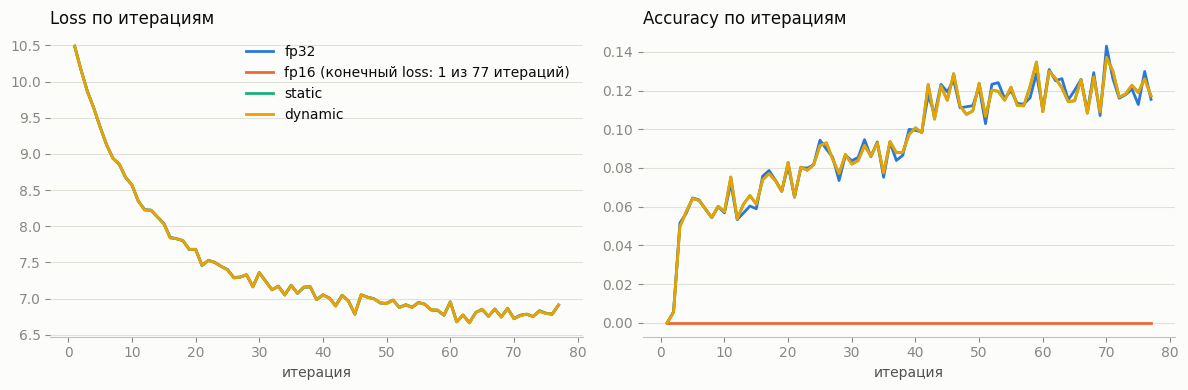

In [61]:
import matplotlib.pyplot as plt

COLORS = {"fp32": "#2a78d6", "fp16": "#eb6834", "static": "#1baf7a", "dynamic": "#eda100"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor="#fcfcfb")
for ax, key, title in zip(axes, ["loss", "accuracy"], ["Loss по итерациям", "Accuracy по итерациям"]):
    for kind, stats in RESULTS.items():
        values = np.array(stats[key], dtype=np.float64)
        finite = int(np.isfinite(np.array(stats['loss'], dtype=np.float64)).sum())
        label = kind if finite == len(values) else f"{kind} (конечный loss: {finite} из {len(values)} итераций)"
        ax.plot(np.arange(1, len(values) + 1), values, color=COLORS[kind], linewidth=2, label=label)
    ax.set_title(title, loc="left", color="#0b0b0b")
    ax.set_xlabel("итерация", color="#52514e")
    ax.set_facecolor("#fcfcfb")
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
    ax.tick_params(colors="#898781")
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
axes[0].legend(frameon=False, labelcolor="#0b0b0b")
fig.tight_layout()
fig.savefig(WORK_DIR / "amp_comparison.png", dpi=150)
plt.show()

In [62]:
BAD_SCALE = 2.0**24
RESULTS_SCALE = {}
for kind in ["static", "dynamic"]:
    RESULTS_SCALE[kind] = train(SimpleNamespace(**{**vars(CONFIG), "kind": kind, "scale": BAD_SCALE}))
    gc.collect()
    torch.cuda.empty_cache()

for kind, stats in RESULTS_SCALE.items():
    losses = np.array(stats['loss'], dtype=np.float64)
    print(f"{kind:8} loss {losses[-TAIL:].mean():.4f}  scale {stats['scale'][0]:.0f} -> {stats['scale'][-1]:.0f}")

0it [00:00, ?it/s]

0it [00:00, ?it/s]

static   loss 10.4812  scale 16777216 -> 16777216
dynamic  loss 6.8246  scale 16777216 -> 524288


In [63]:
LOADERS = ["base", "standard", "balanced", "sequenced"]
RESULTS_DATA = {}
for loader in LOADERS:
    print(f"=== dataloader: {loader} ===")
    RESULTS_DATA[loader] = train(SimpleNamespace(**{**vars(CONFIG), "kind": "static", "dataloader": loader}))
    gc.collect()
    torch.cuda.empty_cache()

print(f"{'dataloader':10} {'iters':>5} {'prep, s':>8} {'train, s':>9} {'peak mem, MB':>13} {'loss':>8}")
for loader, stats in RESULTS_DATA.items():
    losses = np.array(stats['loss'], dtype=np.float64)
    print(f"{loader:10} {len(losses):5d} {stats['prep_time']:8.2f} {stats['train_time']:9.2f} "
          f"{stats['peak_memory_mb']:13.0f} {losses[-TAIL:].mean():8.4f}")

=== dataloader: base ===


0it [00:00, ?it/s]

=== dataloader: standard ===


0it [00:00, ?it/s]

=== dataloader: balanced ===


0it [00:00, ?it/s]

=== dataloader: sequenced ===


0it [00:00, ?it/s]

dataloader iters  prep, s  train, s  peak mem, MB     loss
base          77     0.21     37.81          6380   6.7937
standard      77     0.56     23.67          5942   6.7979
balanced      88     0.54     11.03          6057   6.4775
sequenced    577     0.56     28.02          2199   6.2743


In [64]:
LOADERS = ["base", "standard", "balanced", "sequenced"]
RESULTS_DATA = {}
for loader in LOADERS:
    print(f"=== dataloader: {loader} ===")
    RESULTS_DATA[loader] = train(SimpleNamespace(**{**vars(CONFIG), "kind": "dynamic", "dataloader": loader}))
    gc.collect()
    torch.cuda.empty_cache()

print(f"{'dataloader':10} {'iters':>5} {'prep, s':>8} {'train, s':>9} {'peak mem, MB':>13} {'loss':>8}")
for loader, stats in RESULTS_DATA.items():
    losses = np.array(stats['loss'], dtype=np.float64)
    print(f"{loader:10} {len(losses):5d} {stats['prep_time']:8.2f} {stats['train_time']:9.2f} "
          f"{stats['peak_memory_mb']:13.0f} {losses[-TAIL:].mean():8.4f}")

=== dataloader: base ===


0it [00:00, ?it/s]

=== dataloader: standard ===


0it [00:00, ?it/s]

=== dataloader: balanced ===


0it [00:00, ?it/s]

=== dataloader: sequenced ===


0it [00:00, ?it/s]

dataloader iters  prep, s  train, s  peak mem, MB     loss
base          77     0.22     37.82          6380   6.7937
standard      77     0.53     23.62          5942   6.7979
balanced      88     0.55     11.01          6057   6.4774
sequenced    577     0.56     27.94          2200   6.2801


## 6. Профилирование, отчёт и бонусы

### `Profiling (1 балл)`

Зафиксируйте оптимальный с вашей точки зрения сетап, дальнейшее задание выполняйте в нем.

**Задание**
- В коде оставлено несколько неэффективностей. Используя профилировщик, найдите и исправьте их.
- Напишите, какие неэффективности вы нашли, объясните, почему это неэффективно и покажите, как изменился профиль обучения после их устранения
- За первые 5 найденных неэффективностей вы получите по 0.2 балла

In [65]:
from torch.profiler import profile, schedule, tensorboard_trace_handler

OPTIMAL_SETUP = dict(kind="dynamic", dataloader="sequenced")
TRACE_DIR = WORK_DIR / "traces"


def profile_training(name, wait=2, warmup=2, active=5):
    """Profile `active` training steps in OPTIMAL_SETUP, as in bench_attention.py from seminar 02."""
    trace_dir = TRACE_DIR / name
    with profile(
        schedule=schedule(wait=wait, warmup=warmup, active=active, repeat=1),
        on_trace_ready=tensorboard_trace_handler(str(trace_dir)),
        record_shapes=True,
        profile_memory=True,
        with_stack=True,
    ) as prof:
        train(
            SimpleNamespace(**{**vars(CONFIG), **OPTIMAL_SETUP}),
            profiler=prof,
            max_steps=wait + warmup + active,
        )
    gc.collect()
    torch.cuda.empty_cache()
    return prof, trace_dir


PROF_BEFORE, TRACE_BEFORE = profile_training("before")
print("Трасса для Perfetto:", *TRACE_BEFORE.glob("*.pt.trace.json"), sep="\n")

0it [00:00, ?it/s]

Трасса для Perfetto:
/kaggle/working/traces/before/5eee6f012e9b_49.1791368110958685600.pt.trace.json
/kaggle/working/traces/before/5eee6f012e9b_49.1791367483254594369.pt.trace.json


In [66]:
import json

SUSPECTS = {
    "aten::item": ".item(); долгий вызов = CPU ждёт GPU",
    "aten::_local_scalar_dense": "то же, внутренняя операция .item()",
    "cudaStreamSynchronize": "ожидание GPU (item, nonzero, synchronize)",
    "cudaDeviceSynchronize": "torch.cuda.synchronize()",
    "aten::nonzero": "индексация булевой маской",
    "aten::zero_": "запись нулей в тензоры (zero_grad без set_to_none)",
    "aten::isfinite": "проверка градиентов в скейлере",
    "aten::mul_": "деление градиентов на scale",
    "aten::linear": "линейные слои",
    "aten::to": "приведение типа / перенос на устройство",
    "aten::copy_": "копирование данных",
    "aten::masked_fill_": "построение маски внимания",
    "aten::argmax": "accuracy",
    "Optimizer.step#Adam.step": "шаг оптимизатора",
}


def load_trace(trace_dir):
    path = max(Path(trace_dir).glob("*.pt.trace.json"), key=lambda p: p.stat().st_mtime)
    with open(path) as trace_file:
        trace = json.load(trace_file)
    return path, [event for event in trace["traceEvents"] if event.get("ph") == "X"]


def summarize_trace(trace_dir, top=12):
    path, events = load_trace(trace_dir)
    steps = [e for e in events if e.get("cat") == "user_annotation" and e["name"].startswith("ProfilerStep#")]
    num_steps = len(steps)
    step_ms = sum(e["dur"] for e in steps) / num_steps / 1000
    print(f"{path.name}: {path.stat().st_size / 2**20:.1f} МБ, шагов в трассе: {num_steps}, средний шаг: {step_ms:.1f} мс\n")

    stats = {}
    for event in events:
        category, name = event.get("cat"), event["name"]
        if category in ("user_annotation", "gpu_user_annotation", "Trace", "python_function"):
            continue
        entry = stats.setdefault(category, {}).setdefault(name, [0, 0.0, 0.0])
        entry[0] += 1
        entry[1] += event["dur"]
        entry[2] = max(entry[2], event["dur"])

    print(f"{'категория':18} {'событий/шаг':>12} {'мс/шаг':>10}")
    for category, names in sorted(stats.items(), key=lambda item: -sum(v[1] for v in item[1].values())):
        calls = sum(v[0] for v in names.values()) / num_steps
        total_ms = sum(v[1] for v in names.values()) / num_steps / 1000
        print(f"{category:18} {calls:12.1f} {total_ms:10.2f}")

    kernel_ms = sum(v[1] for v in stats.get("kernel", {}).values()) / num_steps / 1000
    if kernel_ms:
        print(f"\nGPU занят kernel-ами {kernel_ms:.1f} мс из {step_ms:.1f} мс шага ({kernel_ms / step_ms:.0%})")

    for category in ("kernel", "gpu_memcpy", "gpu_memset", "cuda_runtime", "cpu_op"):
        names = stats.get(category)
        if not names:
            continue
        print(f"\nТоп по времени, категория {category}:")
        print(f"  {'имя':58} {'вызовов/шаг':>12} {'мс/шаг':>9} {'% шага':>7}")
        for name, (calls, duration, _) in sorted(names.items(), key=lambda item: -item[1][1])[:top]:
            ms = duration / num_steps / 1000
            print(f"  {name[:58]:58} {calls / num_steps:12.1f} {ms:9.3f} {ms / step_ms:7.1%}")

    print("\nНа что смотреть:")
    print(f"  {'имя':28} {'вызовов/шаг':>12} {'мс/шаг':>9} {'макс, мс':>9}  что это")
    merged = {}
    for names in stats.values():
        for name, (calls, duration, longest) in names.items():
            entry = merged.setdefault(name, [0, 0.0, 0.0])
            entry[0] += calls
            entry[1] += duration
            entry[2] = max(entry[2], longest)
    for name, meaning in SUSPECTS.items():
        if name in merged:
            calls, duration, longest = merged[name]
            print(f"  {name:28} {calls / num_steps:12.1f} {duration / num_steps / 1000:9.3f} {longest / 1000:9.3f}  {meaning}")


sort_by = "self_cuda_time_total" if torch.cuda.is_available() else "self_cpu_time_total"
print(PROF_BEFORE.key_averages().table(sort_by=sort_by, row_limit=15))
summarize_trace(TRACE_BEFORE)

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us     244.579ms       112.00%     244.579ms      48.916ms           0 B           0 B           0 B           0 

In [75]:
FIXES_OFF = dict(
    fused_adam=False,            
    zero_grad_to_none=False,     
    fast_finite_check=False,     
    dense_loss=False,            
    log_every=1,                 
    skip_dead_projection=False,  
    cache_causal_mask=False,     
    hidden_dim=1020,             
)
FIXES_ON = dict(
    fused_adam=True, zero_grad_to_none=True, fast_finite_check=True, dense_loss=True, log_every=10,
    skip_dead_projection=True, cache_causal_mask=True,
)


class DenseLMCrossEntropyLoss(torch.nn.CrossEntropyLoss):
    def forward(self, outputs, tokens, tokens_lens, loss_mask=None):
        logits = outputs[:, :-1]
        targets = tokens[:, 1:]
        if loss_mask is not None:
            mask = loss_mask.to(device=tokens.device, dtype=torch.bool)
        else:
            tokens_lens = torch.as_tensor(tokens_lens, device=tokens.device)
            positions = torch.arange(tokens.shape[1] - 1, device=tokens.device)
            mask = positions[None, :] < (tokens_lens[:, None] - 1)
        targets = targets.masked_fill(mask.logical_not(), self.ignore_index)
        return super().forward(logits.flatten(0, 1), targets.flatten())


def collect_grads(optimizer):
    return [param.grad for group in optimizer.param_groups for param in group["params"] if param.grad is not None]


def all_finite_one_pass(grads):
    return torch.stack([grad.sum(dtype=torch.float32) for grad in grads]).isfinite().all().item()


class FastStaticGradScaler(StaticGradScaler):
    def step(self, optimizer):
        with torch.no_grad():
            grads = collect_grads(optimizer)
            if grads and not all_finite_one_pass(grads):
                optimizer.zero_grad()
                return
            for grad in grads:
                grad.mul_(self.inv_scale)
        optimizer.step()


class FastDynamicGradScaler(DynamicGradScaler):
    def step(self, optimizer):
        with torch.no_grad():
            grads = collect_grads(optimizer)
            if grads and not all_finite_one_pass(grads):
                optimizer.zero_grad()
                self._scale = max(self._scale / self.factor, self.min_scale)
                self.counter = 0
                return
            for grad in grads:
                grad.mul_(1 / self._scale)
        optimizer.step()
        self.counter += 1


class FixedGPT2LikeModel(GPT2LikeModel):
    def __init__(self, vocab_size, hidden_dim=1020, skip_dead_projection=True, cache_causal_mask=True):
        super().__init__(vocab_size, hidden_dim=hidden_dim)
        self.skip_dead_projection = skip_dead_projection
        max_length = self.positional_encoding.pe.shape[0]
        causal_mask = torch.full((max_length, max_length), float("-inf")).triu_(diagonal=1)
        self.register_buffer("causal_mask", causal_mask if cache_causal_mask else None, persistent=False)

    def forward(self, x, attention_mask):
        x = x.transpose(0, 1) 
        x = self.embedding(x)
        x = self.positional_encoding(x)
        x = self.hidden_projector(x)
        if not self.skip_dead_projection:
            y = self.hidden_projector2(x)
        if attention_mask is None and self.causal_mask is not None:
            attention_mask = self.causal_mask[:x.size(0), :x.size(0)]
        elif attention_mask is None:
            attention_mask = torch.tril(
                torch.ones((x.size(0), x.size(0)), dtype=torch.bool, device=x.device)
            )
        else:
            attention_mask = attention_mask.to(x.device)
        if attention_mask.dtype == torch.bool:
            attention_mask = torch.zeros_like(attention_mask, dtype=torch.float32).masked_fill_(
                attention_mask.logical_not(), float("-inf")
            )
        attention_mask = attention_mask.to(x.dtype)

        out = self.decoder(tgt=x, memory=x, tgt_mask=attention_mask, memory_mask=attention_mask)
        out = self.output_linear(out)
        return out.transpose(0, 1)


def train_epoch_fixed(train_loader, model, criterion, metric, optimizer, device, kind, scaler, args,
                      profiler=None, max_steps=None):
    model.train()
    autocast = Autocast(enabled=kind in ('static', 'dynamic'))
    losses, accuracies, scales, events = [], [], [], []
    pbar = tqdm(enumerate(train_loader))
    for i, data in pbar:
        tokens, tokens_lens, attention_mask = data['tokens'].to(device), data['lengthes'], data['attention_mask']
        loss_mask = data.get('loss_mask')
        if loss_mask is not None:
            loss_mask = loss_mask.to(device)
        optimizer.zero_grad(set_to_none=args.zero_grad_to_none)
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        start.record()
        with autocast:
            outputs = model(tokens, attention_mask)
            loss = criterion(outputs, tokens, tokens_lens, loss_mask=loss_mask)
        if kind == 'fp16' or kind == 'fp32':
            loss.backward()
        else:
            scaler.scale(loss).backward()
        end.record()
        events.append((start, end))
        if args.log_every == 1:
            torch.cuda.synchronize()  # the original code waits for the GPU on every step
        scales.append(1.0 if scaler is None else scaler._scale)
        if scaler is None:
            optimizer.step()
        else:
            scaler.step(optimizer)
            scaler.update()
        losses.append(loss.detach())  
        if i % args.log_every == 0:
            accuracy = metric(outputs, tokens, tokens_lens, loss_mask=loss_mask)
            accuracies.append(accuracy)
            pbar.set_description(f"Loss: {round(loss.item(), 4)} " f"Accuracy: {round(accuracy.item() * 100, 4)}")
        if profiler is not None:
            profiler.step()
        if max_steps is not None and i + 1 >= max_steps:
            break
    torch.cuda.synchronize()  
    return {
        'loss': torch.stack(losses).float().tolist(),
        'accuracy': torch.stack(accuracies).float().tolist(),  # one value per log_every steps
        'grad_time': [start.elapsed_time(end) / 1000 for start, end in events],
        'scale': scales,
    }


def train_fixed(args, profiler=None, max_steps=None):
    set_global_seed(42)
    device = torch.device("cuda:0")
    torch.cuda.reset_peak_memory_stats(device)
    prep_start = time.perf_counter()
    dataloader = get_dataloader(args.dataloader, args.batch_size, args.path, args.k)
    prep_time = time.perf_counter() - prep_start
    model = FixedGPT2LikeModel(
        dataloader.dataset.tokenizer.vocab_size,
        hidden_dim=args.hidden_dim,
        skip_dead_projection=args.skip_dead_projection,
        cache_causal_mask=args.cache_causal_mask,
    ).to(device)
    if args.kind == 'fp16':
        model = model.half()
    criterion = DenseLMCrossEntropyLoss() if args.dense_loss else LMCrossEntropyLoss()
    metric = LMAccuracy()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, fused=True if args.fused_adam else None)
    scaler = None
    if args.kind == 'static':
        scaler = (FastStaticGradScaler if args.fast_finite_check else StaticGradScaler)(args.scale)
    elif args.kind == 'dynamic':
        scaler = (FastDynamicGradScaler if args.fast_finite_check else DynamicGradScaler)(
            scale=args.scale,
            factor=args.factor,
            patience=args.patience,
            min_scale=args.min_scale,
            max_scale=args.max_scale,
        )
    stats = {'loss': [], 'accuracy': [], 'grad_time': [], 'scale': []}
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    start.record()
    for epoch in range(0, args.num_epochs):
        epoch_stats = train_epoch_fixed(
            train_loader=dataloader,
            model=model,
            criterion=criterion,
            metric=metric,
            optimizer=optimizer,
            device=device,
            kind=args.kind,
            scaler=scaler,
            args=args,
            profiler=profiler,
            max_steps=max_steps,
        )
        for key, values in epoch_stats.items():
            stats[key].extend(values)
    end.record()
    torch.cuda.synchronize()
    stats['prep_time'] = prep_time
    stats['train_time'] = start.elapsed_time(end) / 1000
    stats['peak_memory_mb'] = torch.cuda.max_memory_allocated(device) / 2**20
    return stats

def run_fixed(profiler=None, max_steps=None, **fixes):
    args = SimpleNamespace(**{**vars(CONFIG), **OPTIMAL_SETUP, **FIXES_OFF, **fixes})
    stats = train_fixed(args, profiler=profiler, max_steps=max_steps)
    gc.collect()
    torch.cuda.empty_cache()
    return stats

In [76]:
ABLATION_STEPS = [
    ("исходный код", {}),
    ("+ fused Adam", dict(fused_adam=True)),
    ("+ zero_grad(set_to_none=True)", dict(zero_grad_to_none=True)),
    ("+ проверка градиентов за 1 проход", dict(fast_finite_check=True)),
    ("+ loss без булевой индексации", dict(dense_loss=True)),
    ("+ .item() и accuracy раз в 10 шагов", dict(log_every=10)),
    ("+ без hidden_projector2", dict(skip_dead_projection=True)),
    ("+ hidden_dim 1020 -> 1024", dict(hidden_dim=1024)),
]
RESULTS_ABLATION = {}

fixes = {}
for name, change in ABLATION_STEPS:
    fixes.update(change)
    print(f"=== {name} ===")
    RESULTS_ABLATION[name] = run_fixed(**fixes)

baseline_time = previous_time = RESULTS_ABLATION["исходный код"]['train_time']
print(f"{'шаг':36} {'iters':>5} {'train, s':>9} {'мс/шаг':>7} {'к пред.':>8} {'к исх.':>7} {'peak mem, MB':>13} {'loss':>8}")
for name, stats in RESULTS_ABLATION.items():
    losses = np.array(stats['loss'], dtype=np.float64)
    print(
        f"{name:36} {len(losses):5d} {stats['train_time']:9.2f} {stats['train_time'] / len(losses) * 1000:7.1f} "
        f"{previous_time / stats['train_time']:7.2f}x {baseline_time / stats['train_time']:6.2f}x "
        f"{stats['peak_memory_mb']:13.0f} {losses[-TAIL:].mean():8.4f}"
    )
    previous_time = stats['train_time']

=== исходный код ===


0it [00:00, ?it/s]

=== + fused Adam ===


0it [00:00, ?it/s]

=== + zero_grad(set_to_none=True) ===


...

=== + без hidden_projector2 ===


0it [00:00, ?it/s]

=== + hidden_dim 1020 -> 1024 ===


0it [00:00, ?it/s]

шаг                                  iters  train, s  мс/шаг  к пред.  к исх.  peak mem, MB     loss
исходный код                           577     27.79    48.2    1.00x   1.00x          3120   6.2801
+ fused Adam                           577     21.83    37.8    1.27x   1.27x          3122   6.2792
+ zero_grad(set_to_none=True)          577     19.81    34.3    1.10x   1.40x          3018   6.2792
+ проверка градиентов за 1 проход      577     17.15    29.7    1.15x   1.62x          2893   6.2792
+ loss без булевой индексации          577     16.40    28.4    1.05x   1.69x          2893   6.2799
+ .item() и accuracy раз в 10 шагов    577     15.58    27.0    1.05x   1.78x          2893   6.2799
+ без hidden_projector2                577     15.57    27.0    1.00x   1.79x          2894   6.2799
+ hidden_dim 1020 -> 1024              581     15.20    26.2    1.02x   1.83x          2874   6.5045


In [77]:
from torch.autograd import DeviceType


def profile_fixed(name, wait=2, warmup=2, active=10, **fixes):
    trace_dir = TRACE_DIR / name
    with profile(
        schedule=schedule(wait=wait, warmup=warmup, active=active, repeat=1),
        on_trace_ready=tensorboard_trace_handler(str(trace_dir)),
        record_shapes=True,
        profile_memory=True,
        with_stack=True,
    ) as prof:
        run_fixed(profiler=prof, max_steps=wait + warmup + active, **fixes)
    return prof, trace_dir


def device_time(evt):
    return getattr(evt, "self_device_time_total", None) or getattr(evt, "self_cuda_time_total", 0)


def gpu_ms_per_step(prof):
    averages = prof.key_averages()
    num_steps = max(evt.count for evt in averages if evt.key.startswith("ProfilerStep"))
    on_gpu = torch.cuda.is_available()
    operations, optimizer_calls = {}, {}
    for evt in averages:
        if evt.key.startswith("ProfilerStep"):
            continue
        if evt.device_type != DeviceType.CPU:
            # GPU-side rows: kernels (already counted inside the operations) and annotations such as Optimizer.step
            if evt.key.startswith("Optimizer."):
                optimizer_calls[evt.key] = (evt.count / num_steps, device_time(evt) / num_steps / 1000)
            continue
        total = device_time(evt) if on_gpu else evt.self_cpu_time_total
        if total > 0:
            operations[evt.key] = (evt.count / num_steps, total / num_steps / 1000)
    return operations, optimizer_calls


def print_rows(before, after, names):
    for name in names:
        calls_before, ms_before = before.get(name, (0, 0))
        calls_after, ms_after = after.get(name, (0, 0))
        print(f"{name[:44]:44} {calls_before:10.1f}{calls_after:10.1f} {ms_before:10.3f}{ms_after:10.3f}")


def compare_profiles(before, after, top=25):
    (before, before_optimizer), (after, after_optimizer) = gpu_ms_per_step(before), gpu_ms_per_step(after)
    print(f"{'операция':44} {'вызовов/шаг':>20} {'GPU, мс/шаг':>20}")
    print(f"{'':44} {'до':>10}{'после':>10} {'до':>10}{'после':>10}")
    largest = lambda name: -max(before.get(name, (0, 0))[1], after.get(name, (0, 0))[1])
    print_rows(before, after, sorted(set(before) | set(after), key=largest)[:top])
    total_before, total_after = sum(v[1] for v in before.values()), sum(v[1] for v in after.values())
    print(f"{'всего по всем операциям':44} {'':20} {total_before:10.3f}{total_after:10.3f}")
    if before_optimizer or after_optimizer:
        print("\nИз них внутри вызовов оптимизатора:")
        print_rows(before_optimizer, after_optimizer, sorted(set(before_optimizer) | set(after_optimizer)))


PROF_AFTER, TRACE_AFTER = profile_fixed("after", **FIXES_ON)
print("Трасса для Perfetto:", *TRACE_AFTER.glob("*.pt.trace.json"), sep="\n")
compare_profiles(PROF_BEFORE, PROF_AFTER)
summarize_trace(TRACE_AFTER)

0it [00:00, ?it/s]

Трасса для Perfetto:
/kaggle/working/traces/after/5eee6f012e9b_49.1791369894588966931.pt.trace.json
операция                                              вызовов/шаг          GPU, мс/шаг
                                                     до     после         до     после
aten::_fused_adam_                                  0.0       1.0      0.000     7.340
aten::_foreach_addcdiv_                             1.0       0.0      3.846     0.000
aten::copy_                                        93.0      89.3      3.666     3.782
aten::mm                                           18.0      18.0      2.980     3.287
aten::add_                                         55.0       8.0      3.153     0.174
aten::_foreach_lerp_                                1.0       0.0      2.961     0.000
aten::_foreach_addcmul_                             1.0       0.0      2.957     0.000
aten::_foreach_sqrt                                 1.0       0.0      2.092     0.000
aten::_foreach_div_           

### `Отчет (1 балл)`
Соберите все результаты в небольшой отчет. Насколько в сумме удалось ускорить обучение? Какое ускорение дал каждый из этапов?

### `Бонусы (1 балл)`
- (0.75 балла) В `torch.nn.TransformerDecoderLayer` используются `LayerNorm`. Замените их на `FusedLayerNorm` из [Apex](https://nvidia.github.io/apex/layernorm.html) и изучите изменения в скорости работы и потребляемой памяти от этой замены
- (0.25 балла) Используйте `torch.compile` и изучите изменения в скорости работы и потребляемой памяти при его использовании

In [78]:
def train_fixed(args, profiler=None, max_steps=None, model_hook=None):
    set_global_seed(42)
    device = torch.device("cuda:0")
    torch.cuda.reset_peak_memory_stats(device)
    prep_start = time.perf_counter()
    dataloader = get_dataloader(args.dataloader, args.batch_size, args.path, args.k)
    prep_time = time.perf_counter() - prep_start
    model = FixedGPT2LikeModel(
        dataloader.dataset.tokenizer.vocab_size,
        hidden_dim=args.hidden_dim,
        skip_dead_projection=args.skip_dead_projection,
        cache_causal_mask=args.cache_causal_mask,
    ).to(device)
    if args.kind == 'fp16':
        model = model.half()
    if model_hook is not None:
        model = model_hook(model)
    criterion = DenseLMCrossEntropyLoss() if args.dense_loss else LMCrossEntropyLoss()
    metric = LMAccuracy()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, fused=True if args.fused_adam else None)
    scaler = None
    if args.kind == 'static':
        scaler = (FastStaticGradScaler if args.fast_finite_check else StaticGradScaler)(args.scale)
    elif args.kind == 'dynamic':
        scaler = (FastDynamicGradScaler if args.fast_finite_check else DynamicGradScaler)(
            scale=args.scale,
            factor=args.factor,
            patience=args.patience,
            min_scale=args.min_scale,
            max_scale=args.max_scale,
        )
    stats = {'loss': [], 'accuracy': [], 'grad_time': [], 'scale': []}
    epoch_events = [torch.cuda.Event(enable_timing=True) for _ in range(args.num_epochs + 1)]
    epoch_events[0].record()
    for epoch in range(0, args.num_epochs):
        epoch_stats = train_epoch_fixed(
            train_loader=dataloader,
            model=model,
            criterion=criterion,
            metric=metric,
            optimizer=optimizer,
            device=device,
            kind=args.kind,
            scaler=scaler,
            args=args,
            profiler=profiler,
            max_steps=max_steps,
        )
        epoch_events[epoch + 1].record()
        for key, values in epoch_stats.items():
            stats[key].extend(values)
    torch.cuda.synchronize()
    stats['prep_time'] = prep_time
    stats['epoch_time'] = [start.elapsed_time(end) / 1000 for start, end in zip(epoch_events, epoch_events[1:])]
    stats['train_time'] = epoch_events[0].elapsed_time(epoch_events[-1]) / 1000
    stats['peak_memory_mb'] = torch.cuda.max_memory_allocated(device) / 2**20
    return stats


def run_fixed(profiler=None, max_steps=None, model_hook=None, **fixes):
    args = SimpleNamespace(**{**vars(CONFIG), **OPTIMAL_SETUP, **FIXES_OFF, **fixes})
    stats = train_fixed(args, profiler=profiler, max_steps=max_steps, model_hook=model_hook)
    gc.collect()
    torch.cuda.empty_cache()
    return stats

In [79]:
BONUS_EPOCHS = 3
RESULTS_BONUS = {}


def run_bonus(name, model_hook=None):
    print(f"=== {name} ===")
    torch._dynamo.reset()
    RESULTS_BONUS[name] = run_fixed(model_hook=model_hook, num_epochs=BONUS_EPOCHS, **FIXES_ON)


def print_bonus():
    epochs = " ".join(f"{'эпоха ' + str(i + 1) + ', с':>11}" for i in range(BONUS_EPOCHS))
    print(f"{'вариант':26} {epochs} {'peak mem, MB':>13} {'loss':>8}")
    for name, stats in RESULTS_BONUS.items():
        times = " ".join(f"{t:11.2f}" for t in stats['epoch_time'])
        print(f"{name:26} {times} {stats['peak_memory_mb']:13.0f} {np.mean(stats['loss'][-TAIL:]):8.4f}")


run_bonus("все исправления")
run_bonus("+ torch.compile", lambda model: torch.compile(model, dynamic=True))
print_bonus()

=== все исправления ===


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

=== + torch.compile ===


0it [00:00, ?it/s]

W1007 10:58:25.200000 49 torch/_inductor/utils.py:1731] [0/0_1] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.13/dist-packages/torch/_inductor/lowering.py:7836: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(


0it [00:00, ?it/s]

0it [00:00, ?it/s]

вариант                     эпоха 1, с  эпоха 2, с  эпоха 3, с  peak mem, MB     loss
все исправления                  15.88       15.65       15.52          3817   5.4679
+ torch.compile                  44.56       14.89       14.97          3817   5.4602


In [80]:
import subprocess
import sys
import torch.utils.cpp_extension as cpp_extension

APEX_DIR = WORK_DIR / "apex"
print("CUDA_HOME:", cpp_extension.CUDA_HOME, "| CUDA в torch:", torch.version.cuda)
if not APEX_DIR.exists():
    subprocess.run(["git", "clone", "--depth", "1", "https://github.com/NVIDIA/apex", str(APEX_DIR)], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ninja"], check=True)
sys.path.insert(0, str(APEX_DIR))
sys.modules["fused_layer_norm_cuda"] = cpp_extension.load(
    name="fused_layer_norm_cuda",
    sources=[str(APEX_DIR / "csrc" / "layer_norm_cuda.cpp"), str(APEX_DIR / "csrc" / "layer_norm_cuda_kernel.cu")],
    extra_include_paths=[str(APEX_DIR / "csrc")],
    extra_cflags=["-O3"],
    extra_cuda_cflags=["-maxrregcount=50", "-O3", "--use_fast_math"],
)
from apex.normalization import FusedLayerNorm
print("FusedLayerNorm собран:", FusedLayerNorm(8))

CUDA_HOME: /usr/local/cuda | CUDA в torch: 12.8


Cloning into '/kaggle/working/apex'...


FusedLayerNorm собран: FusedLayerNorm(torch.Size([8]), eps=1e-05, elementwise_affine=True)


In [81]:
class Fp32FusedLayerNorm(FusedLayerNorm):
    def forward(self, input):
        return super().forward(input.to(self.weight.dtype))


def use_fused_layer_norm(model):
    for name in ("norm1", "norm2", "norm3"):
        old = getattr(model.decoder, name)
        new = Fp32FusedLayerNorm(old.normalized_shape, eps=old.eps).to(old.weight.device)
        new.load_state_dict(old.state_dict())
        setattr(model.decoder, name, new)
    return model


run_bonus("+ FusedLayerNorm (Apex)", use_fused_layer_norm)
print_bonus()

PROF_APEX, TRACE_APEX = profile_fixed("apex", model_hook=use_fused_layer_norm, **FIXES_ON)
compare_profiles(PROF_AFTER, PROF_APEX, top=15)

=== + FusedLayerNorm (Apex) ===


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

вариант                     эпоха 1, с  эпоха 2, с  эпоха 3, с  peak mem, MB     loss
все исправления                  15.88       15.65       15.52          3817   5.4679
+ torch.compile                  44.56       14.89       14.97          3817   5.4602
+ FusedLayerNorm (Apex)          15.90       15.91       15.93          3817   5.4731


0it [00:00, ?it/s]

операция                                              вызовов/шаг          GPU, мс/шаг
                                                     до     после         до     после
aten::_fused_adam_                                  1.0       1.0      7.340     7.352
aten::copy_                                        89.3      89.3      3.782     3.922
aten::mm                                           18.0      18.0      3.287     3.852
aten::addmm                                         9.0       9.0      2.051     2.459
aten::mul_                                         23.0      23.0      2.053     2.046
aten::bmm                                          12.0      12.0      1.245     1.463
aten::sum                                          32.2      32.2      1.272     1.309
aten::_log_softmax_backward_data                    1.0       1.0      0.888     0.890
aten::_log_softmax                                  1.0       1.0      0.778     0.785
aten::fill_                                

### Сохранение работы

Выполняйте и сравнивайте эксперименты после заполнения заглушек. Зафиксируйте фактическое
окружение и GPU из раздела 1, параметры каждого запуска, внесённые изменения, время и память.
Сохраните выполненный notebook, результаты и отдельный PDF-отчёт по требованиям задания.